## 拉格朗日乘数

### Outline
- 背景
- 拉格朗日乘子法
- 等式约束条件
- 不等式约束条件 - KKT
- 对偶问题

### 背景
在无约束条件下寻找多元函数 $f$ 的极值，常规思路是通过令一阶偏导为零（$\nabla f = \mathbf{0}$）求解驻点，再结合定义域边界或二阶偏导矩阵（Hessian 矩阵）进行判定。但在实际中中，变量往往受到现实规则的限制，这便引入了约束优化问题。

在一元函数中，单纯的等式约束（如 $x = 3$）会让变量失去自由度，问题退化为单一求值；而对于不等式约束（如 $f(x) = x^2 + 2x$ 在 $x \ge 3$ 条件下），我们通常先令导数 $2x + 2 = 0$ 解出驻点 $x = -1$，发现它不在可行域内，再考察边界点 $x = 3$，得到极小值 $f_{\min} = 15$。这种方法在一维数轴上十分直观。

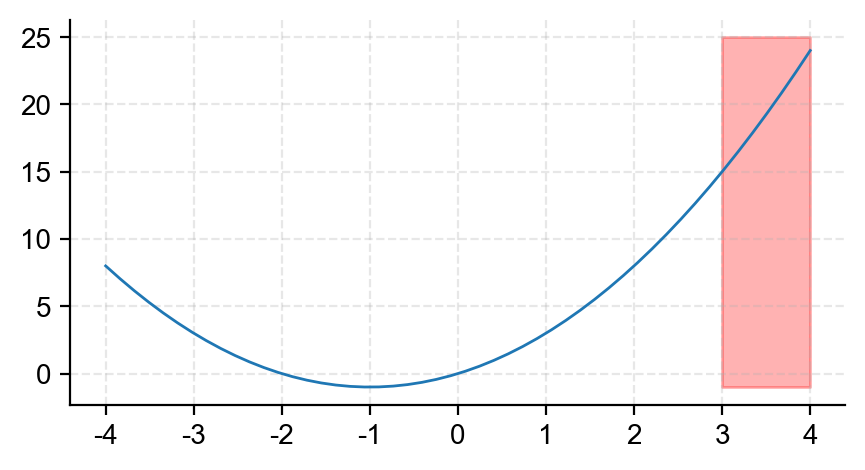

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
x=np.linspace(-4,4)
fx=x**2+2*x
plt.plot(x,fx,lw=1)
x0=np.linspace(3,4)
fx0=x0**2+2*x0
# plt.fill_between(x0,fx0,-1,alpha=0.4)
plt.fill_between(x0,np.full_like(x0,25),-1,alpha=0.3,color='r')

但当问题扩展到二元及以上维度时，几何直观发生了变化。例如求：

比如求$f(x,y)=2+x^2+y^2$在$g(x,y)=x^2+\frac{1}{4}y^2-1=0$条件下的极值。此时定义域不再是数轴区间。虽然部分简单问题可通过消元法降维，但当约束方程高度非线性、无法显式解出变量时，消元法便无法推进。

解决此类等式约束问题，最通用的工具就是拉格朗日乘数法。它的妙处在于，完全打破了“令导数等于零”的固化思维，而是从运动与几何的视角重新审视极值的本质：既然我们被“锁死”在轨道 $g(x,y)=0$ 上行走，那么极值点并不要求函数在整个平面上平坦，只要求我们在沿着这条轨道行进时，目标函数值不再发生改变。为了看清这一点，我们不妨将目光聚焦到平面几何上：

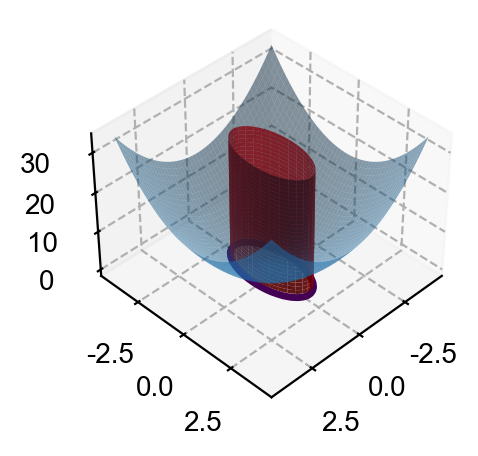

In [ ]:
i=np.linspace(-4,4)
xx,yy=np.meshgrid(i,i)
fx=xx**2+yy**2+2
gx=xx**2+1/4*yy**2-1

fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
# plt.contour(xx,yy,fx,levels=10)
# plt.contour(xx,yy,gx,levels=[0])
ax.plot_surface(xx,yy,fx,alpha=0.5)
ax.contour(xx,yy,gx,levels=[0])


theta = np.linspace(0, 2 * np.pi, 60)   
z_vals = np.linspace(1, 30, 30)         
Theta, Z = np.meshgrid(theta, z_vals)   


X = 1 * np.cos(Theta)   # 短轴为 1
Y = 2 * np.sin(Theta)   # 长轴为 2

ax.plot_surface(X, Y, Z, alpha=0.9, color='r')
ax=plt.gca()
# ax.set_aspect('equal')
ax.view_init(40,45)

几何角度理解

1. 定义域收缩
在f(x,y)原本的定义域是整个2D平面上的点(x,y),现在被限制在g(x,y)=0(g=0等高线)上移动
2. 极值的几何临界态
想象目标函数 $f(x, y)$ 的一系列等高线：
    - 如果约束曲线与f的等高线相交，意味着还可以沿约束曲线继续移动，f的值仍在上升或下降
    - 只有当约束线与f的某条等高线相切，函数值才不变化，此时对应的接触点为极值候选点
3. 相切到代数方程
由微积分知识可知，等高线在任意点处的法向量正是该函数在该点的梯度向量。两曲线在接触点处相切，意味着它们共享同一条切线，因此两者的法向量（梯度）必然在同一直线上（方向相同或相反）：
$$\nabla f(x, y) = \lambda \nabla g(x, y) \quad (\lambda \neq 0)$$

> tip (x,y)定义域是一个平面,f(x,y)表示这个平面所在点的高度，所以很自然的用等高线来可视化f(x,y)的值的变化

拉格朗日方程组

在条件g(x,y)=0下,求f(x,y)的极值候选点只需要解方程
$\begin{cases}\nabla f(x,y) = \lambda \nabla g(x,y)\\
g(x,y)=0 \end{cases}$,其中标量 $\lambda$ 被称为拉格朗日乘数。解出的每一组 $(x, y)$ 均为极值候选点（驻点），最后通过代入计算或结合问题性质比对极值即可。

### 拉格朗日乘子法
在几何上，我们知道了极值点必须同时满足两件事：曲线相切（约束线与原曲线） 与 位于约束线上。但每次都要把这两件事分开列出显得较为松散。拉格朗日最精妙的贡献，在于构造了一个辅助函数（拉格朗日函数），将这两组几何要求融合进了同一个函数的求导中。


等式约束优化问题
<div class="alert alert-info" style="border-radius: 5px;">
  <p>arg minf(x)</p> 
  <p>subject  to:h(x)=0</p>
</div>
其中f(x)和h(x)为连续函数,h(x)=0是约束条件。这两个式子可以联合起来写成

$$
L(x,\lambda)=f(x)+\lambda h(x)
$$
其中$\lambda$为拉格朗日乘子，通过这个$\lambda$就把约束问题转换为无约束的优化问题 $\arg\min L(x)$.这里只要对$L(x,\lambda)$的每一个自变量求一阶导并令其为0，便能自动还原极值所具备的约束条件
$$
\begin{cases}
 \nabla_{x} L(x,\lambda) = \frac{\partial L(x,\lambda)}{\partial x}=\nabla_ f(x)+\lambda \nabla_ h(x)=0    (法向量共线，等高线相切) \\ 
 \nabla_{\lambda} L(x,\lambda) = \frac{\partial L(x,\lambda)}{\partial \lambda}=\nabla_ f(x)+\lambda \nabla_ h(x)=0  (强制在约束曲线上)
\end{cases}
$$

不等式约束问题 KKT条件
<div class="alert alert-info" style="border-radius: 5px;">
  <p>arg minf(x)</p> 
  <p>subject  to:h(x)<=0</p>
</div>

结合上的问题构建拉格朗日函数 $L(x,\lambda)$
$$
L(x,\lambda)=f(x)+\lambda g(x)
$$
与等式不同这里的条件会多几条，这些条件称KKT条件，它是拉格朗日乘数法在不等式约束下的推广，是非线性规划求局部最优解的一阶必要条件
$\begin{cases}
\nabla_{x} L(x,\lambda) =\nabla_ f(x)+\lambda \nabla_ g(x)=0 \\
g(x)<=0 \\
\lambda >=0 \\
\lambda g(x)=0
\end{cases}
$


等式约束将可行限制在一条直线或者曲面上，自变量没有像两侧偏离的余地，而在实际工程中如SVM，更常见的约束是不等式约束g(x)<=0，这是可行解就变成一个区域。
当约束是一个区域时，最优解出现两种情况：
1. 最优解就在区域内部，此时不等式没起作用，极值点只需要满足\nabla f(x)=0，相当于\lambda=0
2. 最优解落在区域边界上，此时不等式起到约束边界的作用，退化为g(x)=0，但此时梯度向量指向具有方向性（目标函数下降的方向必须朝不可行域，否则点会向区域内部移动 - [看作力的相互制约]），因此乘子满足\lambda>=0


In [ ]:
# 缺图 todo

KKT条件
驻点条件

前面说了由于存在极值，索引极值只可能在分界线上和分界线内。所以对应的最优解油两种可能
1. 最优点在内部 g(x)<0
2. 最优点在边界 g(x)=0
KKT最重要的事情之一，就是把这两种情况统一起来.

g(x)<0说明最优解距离边界还有距离，那么约束没限制住

比如 $min(x−2)^2$ 约束 x>=1，最优点x=2，此时它满足x>=1,所以这个约束没影响最优点，那么这就表明这是普通无约束的优化$\nabla f(x)=0$,因此约束力\lambda=0


g(x)=0退化位边界上最优点
比如 $minx^2$ 约束 x>=1，最优点x=0，但它不满足约束条件，所以它只能在边界线上x=1最优解。

这里就可以理解KKT的第一个条件$\nabla_{x} L(x,\lambda) =\nabla_ f(x)+\lambda \nabla_ g(x)=0$，本质上就是目标函数想往最优方向走，但是约束力把这个方向给抵消了

\lambda >=0
g(x)<=0,意味着只能待在g(x)<=这一侧，从第一个条件等式来看把\nabla_ f(x)想像成一股力往最优解，g(x)约束条件是反方向的一股力，当他们平衡是也就是极值点。g(x)它阻止不能向前走，它不能反过来推向不可行区域，所以约束乘子需要正确的方向\lambda>=0。这是一个有方向的不等式约束，约束只能对最优方向施加单向作用

原始可行性
就是必须满足约束条件下求解，规定g(x)<=0，所以找到x必须满足这个条件，否则就是非法答案

对偶可行性
\lambda>=0，保证下降方向确实朝着不可行域

> 对偶可行性与对偶性别混淆，对偶可行性 \lambda>=0 让L(x,\lambda)满足对偶性

互补松弛性
\lambda g(x)=0，上面说\lambda>=0，g(x)<=0和最优解的两种情况这里对应的数学表示
1. g(x)<0 x=2 但约束x>=1此时L(x,\lambda)中\lambda=0表示没约束
2. g(x)=0 x=1 但约束x>=2此时L(x,\lambda)中g(x)=0表示约束上，lambda>0
这里可发现\lambda，g(x)要么一个有作用一个没有作用。这就是互补松弛

| 条件   | 数学形式                           | 人话               |
| ---- | ------------------------------ | ---------------- |
| 驻点   | $(\nabla f+\lambda\nabla g=0$) | 最优方向被约束抵消        |
| 原始可行 | $(g(x)\le0$)                   | \(x\) 必须合法       |
| 对偶可行 | $(\lambda\ge0$)                | 约束作用方向正确         |
| 互补松弛 | $(\lambda g(x)=0$)             | 要么约束没起作用，要么它正好卡住 |


对偶问题

对偶问题是伴随原始优化问题从而转换一个角度来求解。如果说原始问题是在可行域内直接寻找函数最低点，那对偶问题就是从下方寻找能紧紧贴好原始目标函数的最大理论下界$L(x,\lambda)<=f(x)$。

原问题：
\min_x f(x)满足约束，g(x) \le 0，基本思路是直接找一个满足约束x让f(x)尽可能小
引入拉格朗日函数
L(x,\lambda)=f(x)+\lambda g(x) 其中 \lambda\ge0，这时先固定\lambda 让L对x取最小值，现在就是一个关于x的函数，我让它对x取最小值q(\lambda)=\min_x L(x,\lambda)，这时原来关于x的问题，就变成关于\lambda的问题，这个(q(\lambda)) 就叫做对偶函数

为什么q(\lambda)一定是原问题最优的下界
因为 g(x)\le0 \lambda\ge0 所以\lambda g(x)\le0，因此对于任何满足约束x L(x,\lambda)
=f(x)+\lambda g(x)\le f(x)，也就是说对于一个合法的 (x)，(L(x,\lambda)) 一定不会超过原来的 (f(x))。而我们又让 (L) 对 (x) 取最小：q(\lambda)=\min_xL(x,\lambda)，所以q(\lambda)\le f(x)对于合法x都成立。所以对偶函数本质是在给原问题的最优值找一个下界
> 原问题是在“找最好的 (x)”
> 对偶问题是在“找最好的 (\lambda)，让 (L) 给出的下界尽可能接近原问题最优值”。